# RADAR evaluation analysis

This notebook summarizes the OmniHD-pretrained PointPillars RADAR evaluation on TruckScenes. It reads the exported metrics JSON, produces compact tables, and saves one matplotlib figure per analysis view.

The plots describe the current transfer experiment; they do not modify inference code or recompute the metrics.

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import pandas as pd

METRICS_PATH = Path('lidar_trainval_135_metrics.json')
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

with METRICS_PATH.open('r', encoding='utf-8') as handle:
    metrics = json.load(handle)

def percent(value):
    return None if value is None else 100 * value

def save_current_figure(filename):
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()
    return path

def plot_metrics(frame, x, columns, ylabel, title, filename, rotate=0):
    ax = frame.set_index(x)[columns].plot(kind='bar', figsize=(9, 5))
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.legend(title='Metric')
    plt.xticks(rotation=rotate, ha='right' if rotate else 'center')
    return save_current_figure(filename)

## Overall result

The headline result is low absolute detection performance, driven primarily by recall. Localization and orientation errors are reported only for matched true positives.

,mAP (%),Precision (%),Recall (%),F1 (%),ATE (m),ASE,AOE (deg),GT boxes,Predictions
0,17.506,80.162,39.086,52.549,0.442,0.242,8.761,87781,42801


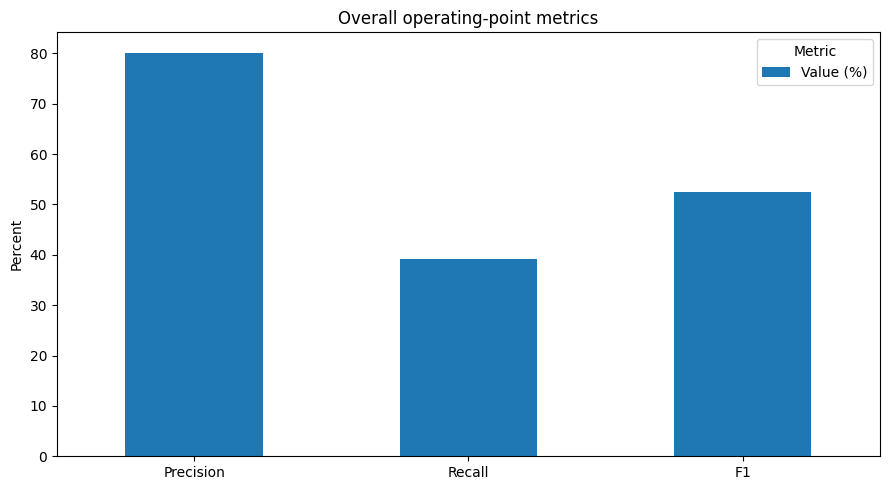

WindowsPath('plots/radar_overall_metrics.png')

In [2]:
op = metrics['overall_metrics']['operating_point']
overall_table = pd.DataFrame([{
    'mAP (%)': percent(metrics['mAP']),
    'Precision (%)': percent(op['precision']),
    'Recall (%)': percent(op['recall']),
    'F1 (%)': percent(op['f1_score']),
    'ATE (m)': op['ate_m'],
    'ASE': op['ase'],
    'AOE (deg)': math.degrees(op['aoe_rad']),
    'GT boxes': op['gt_count'],
    'Predictions': op['prediction_count'],
}]).round(3)
display(overall_table)

overall_plot = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1'],
    'Value (%)': [percent(op['precision']), percent(op['recall']), percent(op['f1_score'])],
})
plot_metrics(overall_plot, 'Metric', ['Value (%)'], 'Percent', 'Overall operating-point metrics', 'radar_overall_metrics.png')

## Class metrics

Car is the only class with non-zero AP at all evaluated distance thresholds. Large vehicles have limited recall with lower precision, while pedestrian and rider detections are effectively absent at the selected operating point.

,Class,mAP (%),Precision (%),Recall (%),F1 (%),ATE (m),ASE,AOE (deg)
0,car,66.494,90.090,52.391,66.253,0.416,0.235,8.470
1,pedestrian,0.000,0.000,0.000,0.000,NaN,NaN,NaN
2,rider,0.000,14.286,0.380,0.739,0.391,0.342,6.031
3,large_vehicle,3.529,31.362,10.697,15.953,0.817,0.336,12.927


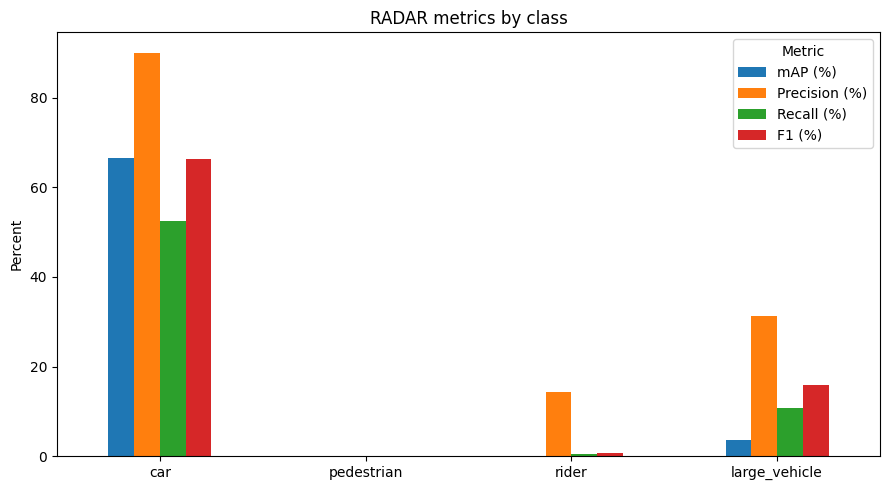

WindowsPath('plots/radar_class_metrics.png')

In [3]:
class_rows = []
for name, values in metrics['class_metrics'].items():
    row = {'Class': name, 'mAP (%)': percent(values['mean_ap'])}
    row.update({'Precision (%)': percent(values['operating_point']['precision']), 'Recall (%)': percent(values['operating_point']['recall']), 'F1 (%)': percent(values['operating_point']['f1_score'])})
    row['ATE (m)'] = values['operating_point']['ate_m']
    row['ASE'] = values['operating_point']['ase']
    row['AOE (deg)'] = (math.degrees(values['operating_point']['aoe_rad']) if values['operating_point']['aoe_rad'] is not None else None)
    class_rows.append(row)
class_table = pd.DataFrame(class_rows).round(3)
display(class_table)
plot_metrics(class_table, 'Class', ['mAP (%)', 'Precision (%)', 'Recall (%)', 'F1 (%)'], 'Percent', 'RADAR metrics by class', 'radar_class_metrics.png')

## Distance breakdown

Recall remains low across the populated distance bins and does not show a simple monotonic collapse with range. The 75–100 m and 100+ m bins contain no ground-truth objects in this export.

,Distance (m),GT count,Precision (%),Recall (%),F1 (%),ATE (m),ASE,AOE (deg)
0,0-25,28610,79.321,45.624,57.928,0.379,0.229,7.307
1,25-50,42670,82.479,38.371,52.376,0.471,0.247,8.645
2,50-75,16501,75.208,29.598,42.479,0.513,0.261,13.035
3,75-100,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100+,0,NaN,NaN,NaN,NaN,NaN,NaN


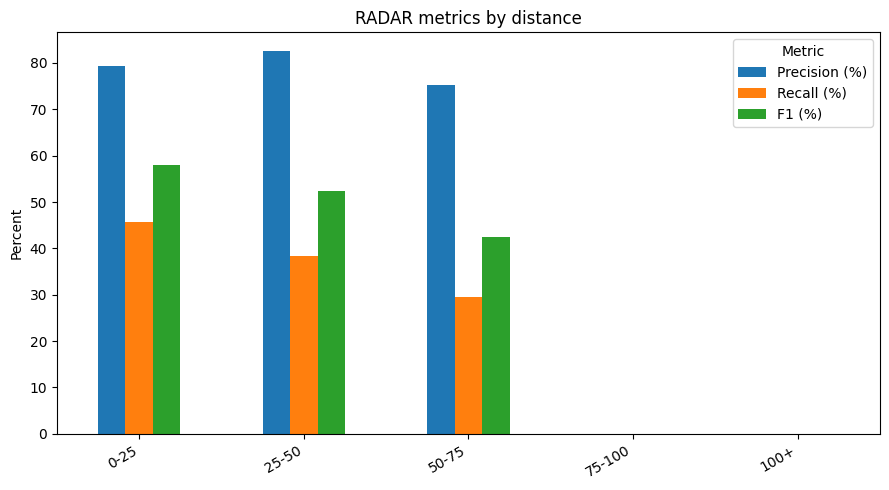

WindowsPath('plots/radar_distance_metrics.png')

In [4]:
def condition_rows(container_key, item_key, label_name):
    rows = []
    for label, values in metrics[container_key][item_key].items():
        rows.append({
            label_name: label,
            'GT count': values['gt_count'],
            'Precision (%)': percent(values.get('precision')),
            'Recall (%)': percent(values.get('recall')),
            'F1 (%)': percent(values.get('f1_score')),
            'ATE (m)': values.get('ate_m'),
            'ASE': values.get('ase'),
            'AOE (deg)': (math.degrees(values['aoe_rad']) if values.get('aoe_rad') is not None else None),
        })
    return pd.DataFrame(rows)

distance_table = condition_rows('distance_metrics', 'bins', 'Distance (m)')
display(distance_table.round(3))
plot_metrics(distance_table, 'Distance (m)', ['Precision (%)', 'Recall (%)', 'F1 (%)'], 'Percent', 'RADAR metrics by distance', 'radar_distance_metrics.png', rotate=30)

## Size breakdown

Small objects have very high precision among the few predictions, but recall is only about 1.4%. Medium objects provide the strongest balance of recall and precision in this evaluation.

,Size,GT count,Precision (%),Recall (%),F1 (%),ATE (m),ASE,AOE (deg)
0,small,29239,99.253,35.446,52.237,0.333,0.288,9.731
1,medium,29279,88.332,57.864,69.923,0.438,0.203,7.693
2,large,29263,53.145,23.935,33.005,0.614,0.267,9.911


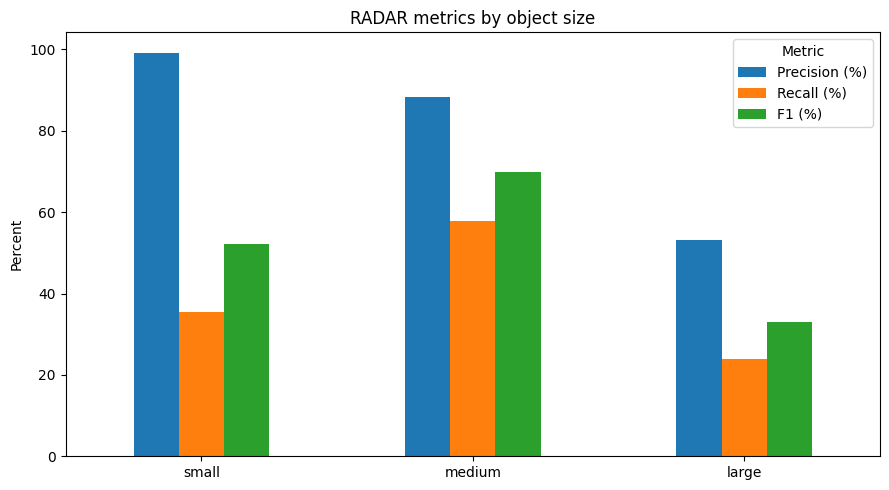

WindowsPath('plots/radar_size_metrics.png')

In [5]:
size_table = condition_rows('size_metrics', 'bins', 'Size')
display(size_table.round(3))
plot_metrics(size_table, 'Size', ['Precision (%)', 'Recall (%)', 'F1 (%)'], 'Percent', 'RADAR metrics by object size', 'radar_size_metrics.png')

## Visibility breakdown

Recall increases substantially for highly visible objects: level 4 is much stronger than levels 1–3. This supports visibility/occlusion as an important limitation of the transferred detector.

,Visibility level,Meaning,GT count,Recall (%),ATE (m),ASE,AOE (deg)
0,1,0-40% visible,15058,14.869,0.470,0.271,9.103
1,2,41-60% visible,8286,28.047,0.423,0.261,10.081
2,3,61-80% visible,10755,35.267,0.413,0.250,7.930
3,4,81-100% visible,53682,48.348,0.446,0.237,8.735


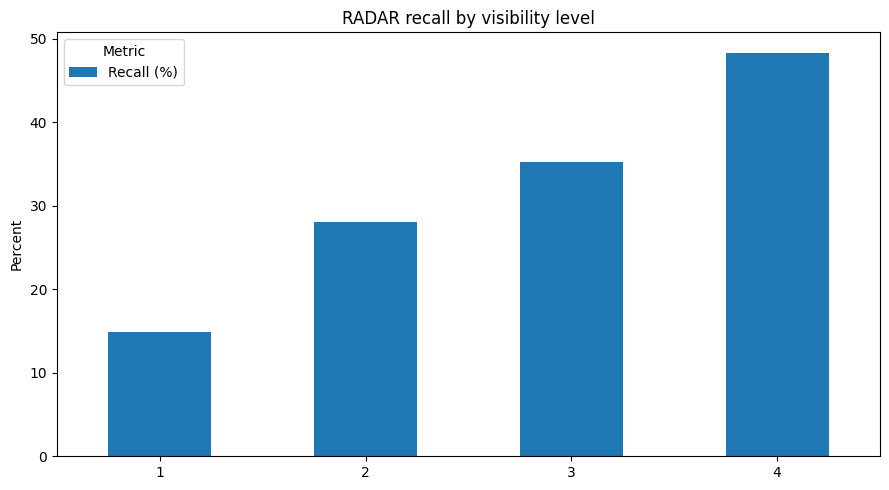

WindowsPath('plots/radar_visibility_metrics.png')

In [6]:
visibility_rows = []
for level, values in metrics['visibility_metrics']['levels'].items():
    visibility_rows.append({
        'Visibility level': level,
        'Meaning': metrics['visibility_metrics']['level_meaning'][level],
        'GT count': values['gt_count'],
        'Recall (%)': percent(values['recall']),
        'ATE (m)': values['ate_m'],
        'ASE': values['ase'],
        'AOE (deg)': math.degrees(values['aoe_rad']),
    })
visibility_table = pd.DataFrame(visibility_rows)
display(visibility_table.round(3))
plot_metrics(visibility_table, 'Visibility level', ['Recall (%)'], 'Percent', 'RADAR recall by visibility level', 'radar_visibility_metrics.png')

## Motion-state breakdown

Moving objects are detected far more often than stationary objects. This is a strong RADAR-specific pattern, but it should be presented as an observation from this transfer experiment rather than proof of sensor causality.

,Motion state,GT count,Precision (%),Recall (%),F1 (%),ATE (m),ASE,AOE (deg)
0,moving,67094,None,45.006,None,0.456,0.240,7.279
1,stationary,19641,None,20.926,None,0.340,0.260,19.654
2,unknown,1046,None,0.382,None,0.391,0.342,6.031


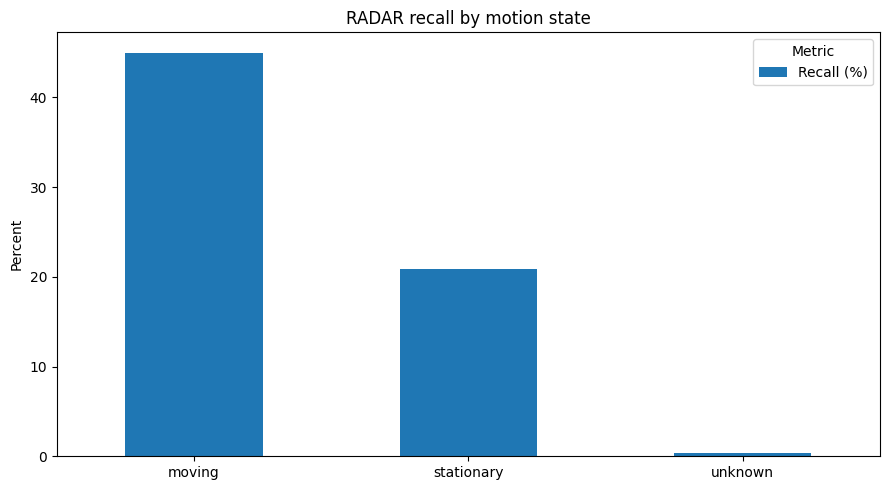

WindowsPath('plots/radar_motion_metrics.png')

In [7]:
motion_table = condition_rows('motion_metrics', 'states', 'Motion state')
display(motion_table.round(3))
plot_metrics(motion_table, 'Motion state', ['Recall (%)'], 'Percent', 'RADAR recall by motion state', 'radar_motion_metrics.png')

## Weather breakdown

Clear scenes have the strongest recall and precision. Rain, fog, and overcast conditions show substantial degradation, so this result does not support claiming better performance under adverse weather for the current transferred model.

,Weather,GT count,Precision (%),Recall (%),F1 (%),ATE (m),ASE,AOE (deg)
0,clear,43810,78.091,41.217,53.955,0.528,0.247,7.452
1,fog,2223,87.803,44.040,58.658,0.553,0.236,1.271
2,other_weather,241,100.000,60.996,75.773,0.286,0.221,7.421
3,overcast,12966,74.601,33.187,45.938,0.422,0.238,22.410
4,rain,21815,86.054,45.455,59.488,0.293,0.235,5.808
5,snow,6726,80.711,13.500,23.131,0.374,0.249,10.650


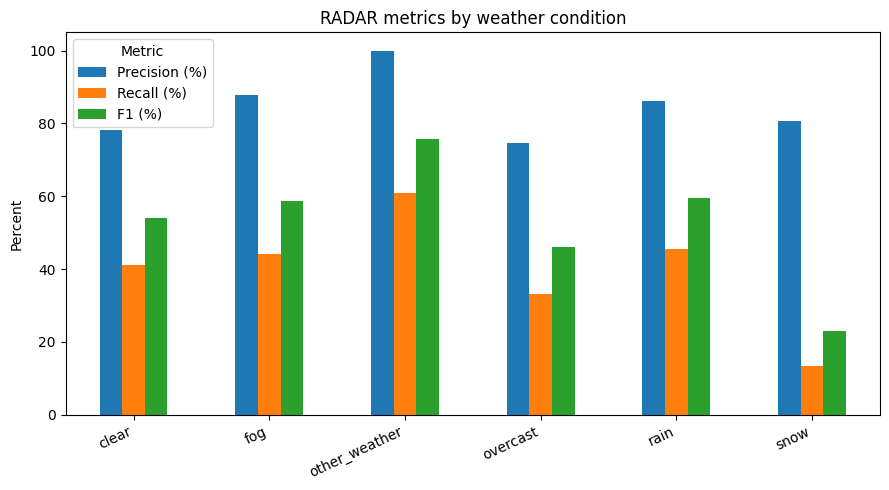

WindowsPath('plots/radar_weather_metrics.png')

In [8]:
weather_table = condition_rows('weather_metrics', 'categories', 'Weather')
display(weather_table.round(3))
plot_metrics(weather_table, 'Weather', ['Precision (%)', 'Recall (%)', 'F1 (%)'], 'Percent', 'RADAR metrics by weather condition', 'radar_weather_metrics.png', rotate=25)

## Area breakdown

Highway scenes dominate the evaluation and have the strongest recall. City, residential, parking, and terminal scenes are much weaker; scene composition and sample counts should be considered when comparing areas.

,Area,GT count,Precision (%),Recall (%),F1 (%),ATE (m),ASE,AOE (deg)
0,city,16660,84.578,32.425,46.878,0.298,0.245,15.936
1,highway,55818,86.413,45.462,59.579,0.474,0.241,4.412
2,other_area,410,86.096,39.268,53.936,0.345,0.213,19.438
3,parking,1912,72.797,9.937,17.487,0.280,0.229,22.058
4,residential,1991,71.163,30.738,42.932,0.416,0.229,25.772
5,rural,4827,69.896,37.663,48.950,0.477,0.243,33.706
6,terminal,6163,23.925,12.186,16.147,0.423,0.274,24.215


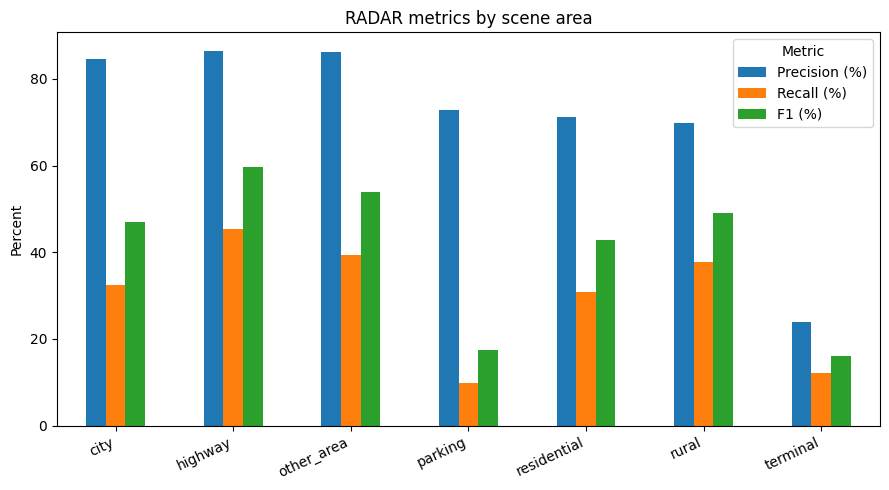

WindowsPath('plots/radar_area_metrics.png')

In [9]:
area_table = condition_rows('area_metrics', 'categories', 'Area')
display(area_table.round(3))
plot_metrics(area_table, 'Area', ['Precision (%)', 'Recall (%)', 'F1 (%)'], 'Percent', 'RADAR metrics by scene area', 'radar_area_metrics.png', rotate=25)